# WESM Price Prediction - Model 3: Neural Network

## Setup and Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 34535 entries, 0 to 34534
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            34535 non-null  datetime64[us]
 1   GWAP                34535 non-null  float64       
 2   energy_demand_mw    34535 non-null  float64       
 3   energy_supply_mw    34535 non-null  float64       
 4   energy_shortage_mw  34535 non-null  float64       
 5   reserve_demand_mw   34535 non-null  float64       
 6   reserve_supply_mw   34535 non-null  float64       
 7   outage_count        34535 non-null  float64       
 8   GWAP_Lag_1          34535 non-null  float64       
 9   GWAP_Lag_12         34535 non-null  float64       
 10  GWAP_Lag_288        34535 non-null  float64       
 11  hour_sin            34535 non-null  float64       
 12  hour_cos            34535 non-null  float64       
 13  dow_1               34535 non-null  int64         
 14  d

The features that will be considered as input in this Neural Network are as follows:

| Feature             | Justification                                      |
|--------------------|----------------------------------------------------|
| energy_demand_mw    | Higher demand drives up price                      |
| energy_supply_mw    | Higher supply brings down price                   |
| reserve_demand_mw   | Reserve requirements affect market tightness      |
| reserve_supply_mw   | Reserve availability affects market stability     |
| outage_count        | More outages reduce available capacity, pushing price up |
| GWAP_Lag_1          | Strong autoregressive signal (price 5 minutes ago) |
| GWAP_Lag_12         | Intra-hour price memory (1 hour ago)              |
| GWAP_Lag_288        | Same-time-yesterday seasonality (24 hours ago)   |
| hour_sin, hour_cos  | Cyclical encoding of intraday price patterns     |
| dow_1 to dow_6      | Day-of-week effects (weekday vs. weekend demand) |

`Note`: `energy_shortage_mw` was not included because it is simply a combination of the two already existing features: `energy_demand_mw` and `energy_supply_mw`. 

In [4]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of features: 16
Features: ['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


---

## Splitting the Data

Dividing the dataset into training set, validation set, and test set. The **test set** and **validation set** will contain 20% of the original dataset, while the **training set** will contain 60%.

A previous iteration of this consisted of the split being 70% allocated to the **training set**, and 15% each for the **validation set** and the **test set**. This distribution was modified because the validation set had very little spikes in comparison to the training set and test set. This meant that the validation set was **not a true representative of the test set**, which led overfitting to the validation set during hyperparameter tuning.

In [5]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  20721 rows | 2025-10-29 to 2026-01-08
Val   :   6907 rows | 2026-01-08 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


The dataset spans approximately 4 months (late October 2025 to late February 2026). The split is:

- **Train**: first 60% of rows (~Oct 29 – Jan 8)
- **Validation**: next 20% of rows (~Jan 8 – Feb 1)
- **Test**: final 20% of rows (~Feb 1 – Feb 26)

Let us make this data splitting easier to visualize.

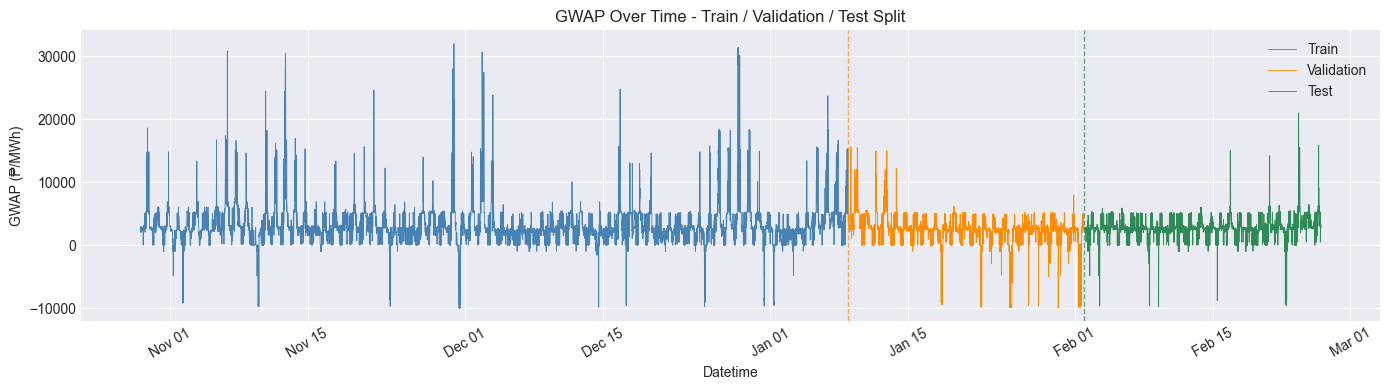

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("GWAP Over Time - Train / Validation / Test Split")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Now, we will segragate the input features with the target feature per set.

In [7]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

---

## Standardizing the Data

Since we are working with high-magnitude values, we will standardize our data to lessen the probability of overshooting. We will only fit on training data to prevent data leakage.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
X_test = scaler_X.transform(X_test)
X_val = scaler_X.transform(X_val)  

In [9]:
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# fit on training data only to prevent data leakage (happens when using test data to compute mean/std)
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))
y_val = scaler_y.transform(y_val.values.reshape(-1, 1))

---

## Converting to Tensor

Convert the np.ndarrays to datatype torch.Tensor

In [10]:
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)
X_val = torch.Tensor(X_val)
y_val = torch.Tensor(y_val)

---

## Setting up the Neural Network

First, we import the NeuralNetwork class

In [11]:
from neural_network import NeuralNetwork

The model we will use will have the following parameters:
- `input_size`: 11 features
- `hidden_layers`: [64, 32]
- `output_size`: 1
- `activation`: relu

We are creating a Neural Network that takes in **11 features** with **2 hidden layers**, where there are **64 neurons** in the first hidden layer and **32 neurons** in the second hidden layer.

Since we are using **regression**, there will only be 1 output neuron. The activation function we will use for the hidden layers is **reLu**.

In [12]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [64, 32]      # to be tuned
output_size = 1

model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation='relu')

We then create the network and initialize the weights

In [13]:
model.create_network()
model.init_weights()
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


---

## Setting the Loss Function and Optimizer

This model will use the **Huber Loss Function** for evaluation and **Adam** as the optimizer with a learning rate of **0.001**.

`Note`: The **Huber Loss Function** was chosen because it combines the best properties of common loss functions such as *Mean Squared Error* and *Mean Absolute Error*. Since our data somewhat relies on the amount of outliers, in order to account for small prediction errors while not completely ignoring the outliers, we use this loss function. **Adam** was chosen as the optimizer because of its optimal performance against other optimizers.

In [14]:
criterion = nn.HuberLoss()  
learning_rate = 0.001      
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

---

## Training

The training pipeline follows the typical progression of a neural network.

1. Empty the gradients of the network.
2. Forward propagation
3. Compute the loss
4. Backward propagation
5. Update parameters

We will use mini-batch gradient descent to train our model. We will use our Dataloader object to handle batch segragation and pass **32** as our batch size.

In [15]:
from data_laoder import DataLoader

batch_size = 32  # to be tuned
data_loader = DataLoader(X_train, y_train, batch_size)

We will have a maximum epoch of **400**. We will also check if the values are converging, determined if the difference in loss of each epoch is less than **0.00005**

`Note`: `model(X)` is called instead of `model.forward` since it automatically calls the forward method with gradient tracking, hooks, distributed training support, and mixed precision support.

In [16]:
epoch = 0
max_epochs = 400
is_converged = False
previous_loss = 0
losses = []

# For each epoch
while epoch <= max_epochs and is_converged is not True:
    
    current_epoch_loss = 0
    
    # Get the batch for this epoch.
    X_batch, y_batch = data_loader.get_batch()
    
    # For each batch
    for X, y in zip(X_batch, y_batch):
        X = torch.Tensor(X)
        # y = torch.Tensor(y).to(torch.long)
        y = torch.Tensor(y)
        
        model.train()

        # Empty the gradients of the network.
        optimizer.zero_grad()
        
        # Forward propagation
        y_pred = model(X) # calls the forward method but adding gradient tracking, hooks, extra support
        
        # Compute the loss
        loss = criterion(y_pred, y)
        
        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()
        
        current_epoch_loss += loss.item()
    
    average_loss = current_epoch_loss / len(X_batch)
    losses.append(average_loss)
    
    # Display the average loss per epoch
    if epoch % 20 == 0:
        print('Epoch:', epoch, '\tLoss: {:.6f}'.format(average_loss))
    
    if abs(previous_loss - loss) < 0.00005:
        is_converged = True
    else:
        previous_loss = loss
        epoch += 1

Epoch: 0 	Loss: 0.083699
Epoch: 20 	Loss: 0.056696
Epoch: 40 	Loss: 0.053574
Epoch: 60 	Loss: 0.051764
Epoch: 80 	Loss: 0.049777
Epoch: 100 	Loss: 0.048276
Epoch: 120 	Loss: 0.047409
Epoch: 140 	Loss: 0.046379
Epoch: 160 	Loss: 0.045251
Epoch: 180 	Loss: 0.044601
Epoch: 200 	Loss: 0.043724
Epoch: 220 	Loss: 0.042675
Epoch: 240 	Loss: 0.042369
Epoch: 260 	Loss: 0.041803
Epoch: 280 	Loss: 0.041405
Epoch: 300 	Loss: 0.040942
Epoch: 320 	Loss: 0.040542
Epoch: 340 	Loss: 0.040234
Epoch: 360 	Loss: 0.039867
Epoch: 380 	Loss: 0.039422
Epoch: 400 	Loss: 0.039076


### Loss for Each Epoch 

Text(0.5, 1.0, 'Loss for each epoch')

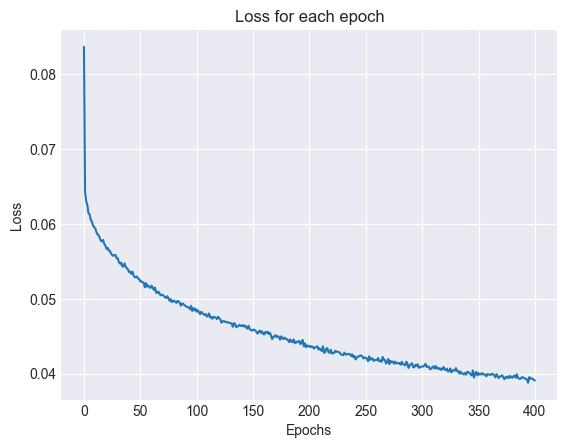

In [17]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each epoch')

As can be seen by the plot, the loss gradually decreases with every epoch, with little to no signs of exploding gradients. Our initial loss (0.083699) quickly went down by the 20th epoch, and after 400 epochs, we end up with a final loss value of 0.039076, representing a **53%** decrease.

---

## Evaluating on Test Data

We will now test the performance of our model on the **Test set**. 

Evaluation will be done using the following:

- **RMSE** (Root Mean Squared Error): main metric; same unit as GWAP (₱/MWh), penalizes large errors more heavily.
- **MAE** (Mean Absolute Error): average absolute error; less sensitive to extreme price spikes.
- **Huber**: penalizes small errors quadratically and large errors linearly, less sensitive to extreme price spikes.
- **R²** (Coefficient of Determination): proportion of GWAP variance explained by the model.

`Note`: We use `torch.no_grad`, which disables gradient calculation, since we will **not** be doing backwards propagation when evaluating on the test set.

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y, label, delta=1.0):
    model.eval()
    with torch.no_grad():
        y_pred = model(X)
    
    y_pred_np = scaler_y.inverse_transform(y_pred.detach().numpy())
    y_np = scaler_y.inverse_transform(y.detach().numpy())
    
    rmse = np.sqrt(mean_squared_error(y_np, y_pred_np))
    mae  = mean_absolute_error(y_np, y_pred_np)

    # Huber loss calculation
    error = y_np - y_pred_np
    abs_error = np.abs(error)
    huber = np.where(abs_error <= delta,
                     0.5 * error**2,
                     delta * (abs_error - 0.5 * delta))
    huber = np.mean(huber)

    r2   = r2_score(y_np, y_pred_np)
    print(f"{label:<12} | RMSE: {rmse:>12.4f} | MAE: {mae:>10.4f} | Huber: {huber:>10.4f} | R²: {r2:>8.4f}")
    return y_pred_np, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>18} | {'MAE':>15} | {'Huber':>17} | {'R\u00b2':>13}")
print("-" * 88)

# model evaluated on its own training data
y_train_pred, train_rmse, train_mae, train_r2 = evaluate(model, X_train, y_train, "Train")

# model evaluated on validation (unseen to model)
y_val_pred, val_rmse, val_mae, val_r2 = evaluate(model, X_val, y_val, "Validation")

# model evaluated on test (unseen to model)
y_test_pred, test_rmse, test_mae, test_r2 = evaluate(model, X_test, y_test, "Test")

Split        |               RMSE |             MAE |             Huber |            R²
----------------------------------------------------------------------------------------
Train        | RMSE:     914.5494 | MAE:   471.7603 | Huber:   471.2608 | R²:   0.9018
Validation   | RMSE:    1933.6488 | MAE:  1081.5511 | Huber:  1081.0513 | R²:   0.3684
Test         | RMSE:    1459.5719 | MAE:  1016.8633 | Huber:  1016.3634 | R²:   0.1984


Since we standardized our data earlier, we use `scaler_y.inverse_transform` to return the values to its original scale.

In [19]:
# inverse-transform the predictions to get them back to the original scale
y_test_original = scaler_y.inverse_transform(y_test.numpy())

### Visualization

Now, let us compare the model's predictions against the actual values using a scatter plot.

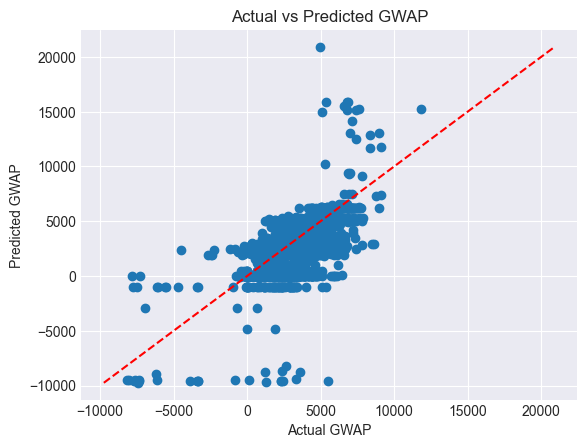

In [20]:
plt.scatter(y_test_pred, y_test_original)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test_original), max(y_test_original)],
         [min(y_test_original), max(y_test_original)],
         'r--')  # perfect prediction line
plt.show()

As seen by the plot above, the model is not that great at predicting the GWAP. There appears to be a big cluster around the ₱0 to ₱5,000 range. Even though the predictions in that area are not completely linear, considering how the data can go up to ₱20,000, it is able to contain itself within that range.

The model seems to have trouble predicting outliers, which is natural because of the natural class imbalance of our dataset. It has a minor tendency to predict values ranging from -₱10,000 to ₱5,000 as ~₱10,000, this might be caused by the high magnitude of the outliers. There also is a trend of the model predicting near ₱0, which makes sense since spikes are a fairly rare ocurrence for GWAPs.

---

## Hyperparameter Tuning

Our current lowest loss is **0.039076** after training on 400 epochs. We will implement hyperparameter tuning on the following parameters in an attempt to better our current model.

Selected parameters to be tuned:

- `hidden_layers` = [[16], [32], [64], [128], [16, 16], [32,32], [64,64], [128,128], [16, 16, 16], [32, 32, 32], [64, 64, 64]]
- `learning_rates` = [0.01, 0.001]
- `batch_sizes` = [32, 64]
- `activation` = ['relu', 'tanh']
- `criterions` = [nn.MSELoss(), nn.L1Loss(), nn.HuberLoss()]

`Note`: The **HuberLoss** function is used with the default `delta` of 1.0. A previous attempt was made to increase its sensitivity, however, this only produced worse results.

In [21]:
hidden_layers = [[16],[32], [64], [128], [16, 16], [32,32], [64,64], [128,128],[16, 16, 16], [32, 32, 32], [64, 64, 64], [128, 128, 128]]
learning_rates = [0.01, 0.001]
batch_sizes = [32, 64, 128]
activation = ['relu', 'tanh']
criterions = [nn.MSELoss(), nn.L1Loss(), nn.HuberLoss()]

We will now determine the best combination of parameters using **Grid-Search**. **Grid-Search** is a method for finding the most optimal set of parameters by testing each combination and essentially brute-forcing it's way to getting the best parameter selection (determined by the one that gives the lowest loss).

In [22]:
def train_and_evaluate(model, optimizer, batch_size, criterion):

    # Validation evaluation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    return val_loss.item()

In [23]:
results = []
best_loss = float('inf')
best_params = None
input_size = X_train.shape[1]

for hidden in hidden_layers:
    for lr in learning_rates:
        for batch in batch_sizes:
            for act in activation:
                for loss_fn in criterions:

                        # print(f"Testing: layers={hidden}, lr={lr}, batch={batch}, act={act}, loss_fn={loss_fn.__class__.__name__}")

                        model = NeuralNetwork(
                            input_size=input_size,
                            num_outputs=1,
                            list_hidden=hidden,
                            activation=act
                        )

                        model.create_network()
                        model.init_weights()

                        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                        val_loss = train_and_evaluate(model, optimizer, batch, loss_fn)

                        # print(f"Validation Loss: {val_loss:.4f}")

                        results.append({
                            "hidden_layers": hidden,
                            "learning_rate": lr,
                            "batch_size": batch,
                            "activation": act,
                            "loss_fn": loss_fn.__class__.__name__,
                            "val_loss": val_loss
                        })

                        if val_loss < best_loss:
                            best_loss = val_loss
                            best_params = results[-1]

print("Best Parameters:")
print(best_params)

Best Parameters:
{'hidden_layers': [32], 'learning_rate': 0.01, 'batch_size': 32, 'activation': 'tanh', 'loss_fn': 'HuberLoss', 'val_loss': 0.21183738112449646}


---

## Updating the Model

Now we have determined the most optimal parameters to use when the model faces unseen data. We will use this to maximize the model's performance in both the training set and the test set.

- `hidden_layers`: [32]
- `learning_rate`: 0.01
- `batch_size`: 32
- `activation`: tanh
- `criterion`: HuberLoss

In [24]:
input_size = X_train.shape[1]  
hidden_layers = [32]     
output_size = 1
activation = 'tanh'

tuned_model = NeuralNetwork(
    input_size=input_size, 
    num_outputs=output_size,
    list_hidden=hidden_layers,
    activation=activation)

In [25]:
tuned_model.create_network()
tuned_model.init_weights()
print(tuned_model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [26]:
criterion = nn.HuberLoss()  
learning_rate = 0.01      
optimizer = torch.optim.Adam(tuned_model.parameters(), lr=learning_rate)

Once again, we will use mini-batch gradient descent to train our model. We will use our Dataloader object to handle batch segragation and pass **32** as our batch size.

In [27]:
from data_laoder import DataLoader

batch_size = 32 
data_loader = DataLoader(X_train, y_train, batch_size)

We shall now train our updated model using the same process as earlier.

In [28]:
epoch = 0
max_epochs = 400
is_converged = False
previous_loss = 0
losses = []

# For each epoch
while epoch <= max_epochs and is_converged is not True:
    
    current_epoch_loss = 0
    
    # Get the batch for this epoch.
    X_batch, y_batch = data_loader.get_batch()
    
    # For each batch
    for X, y in zip(X_batch, y_batch):
        X = torch.Tensor(X)
        # y = torch.Tensor(y).to(torch.long)
        y = torch.Tensor(y)
        
        tuned_model.train()

        # Empty the gradients of the network.
        optimizer.zero_grad()
        
        # Forward propagation
        y_pred = tuned_model(X) # calls the forward method but adding gradient tracking, hooks, extra support
        
        # Compute the loss
        loss = criterion(y_pred, y)
        
        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()
        
        current_epoch_loss += loss.item()
    
    average_loss = current_epoch_loss / len(X_batch)
    losses.append(average_loss)
    
    # Display the average loss per epoch
    if epoch % 20 == 0:
        print('Epoch:', epoch, '\tLoss: {:.6f}'.format(average_loss))
    
    if abs(previous_loss - loss) < 0.00005:
        is_converged = True
    else:
        previous_loss = loss
        epoch += 1

Epoch: 0 	Loss: 0.082487
Epoch: 20 	Loss: 0.065509
Epoch: 40 	Loss: 0.064472
Epoch: 60 	Loss: 0.064054


Text(0.5, 1.0, 'Loss for each epoch')

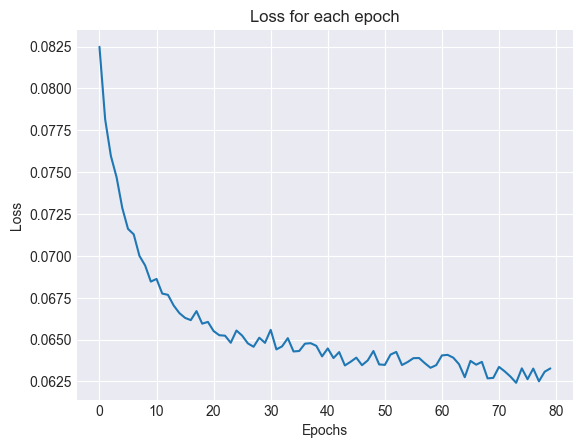

In [29]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each epoch')

As seen by the plot and results of the training session, the model reached **convergence** at around 80 epochs. Similar to the performance from earlier, it seemed to produce a gradual decline in loss (less evident in this plot as it converged earlier). 

`Note`: If we were to continue training past convergence, the model produces worse results.

---

## Evaluating on Test Data

We will now test the performance of our updated model on the **Test set**. We will use the same evaluation metrics as before.

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y, label, delta=1.0):
    model.eval()
    with torch.no_grad():
        y_pred = model(X)
    
    y_pred_np = scaler_y.inverse_transform(y_pred.detach().numpy())
    y_np = scaler_y.inverse_transform(y.detach().numpy())
    
    rmse = np.sqrt(mean_squared_error(y_np, y_pred_np))
    mae  = mean_absolute_error(y_np, y_pred_np)
    
    # Huber loss calculation
    error = y_np - y_pred_np
    abs_error = np.abs(error)
    huber = np.where(abs_error <= delta,
                     0.5 * error**2,
                     delta * (abs_error - 0.5 * delta))
    huber = np.mean(huber)

    r2   = r2_score(y_np, y_pred_np)
    print(f"{label:<12} | RMSE: {rmse:>12.4f} | MAE: {mae:>10.4f} | Huber: {huber:>10.4f} | R²: {r2:>8.4f}")
    return y_pred_np, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>18} | {'MAE':>15} | {'Huber':>17} | {'R\u00b2':>13}")
print("-" * 88)

# model evaluated on its own training data
tuned_y_train_pred, train_rmse, train_mae, train_r2 = evaluate(tuned_model, X_train, y_train, "Train")

# model evaluated on validation (unseen to model)
tuned_y_val_pred, val_rmse, val_mae, val_r2 = evaluate(tuned_model, X_val, y_val, "Validation")

# model evaluated on test (unseen to model)
tuned_y_test_pred, test_rmse, test_mae, test_r2 = evaluate(tuned_model, X_test, y_test, "Test")

Split        |               RMSE |             MAE |             Huber |            R²
----------------------------------------------------------------------------------------
Train        | RMSE:    1188.9839 | MAE:   621.4035 | Huber:   620.9038 | R²:   0.8341
Validation   | RMSE:    1178.4772 | MAE:   663.2000 | Huber:   662.7001 | R²:   0.7654
Test         | RMSE:    1125.3386 | MAE:   720.8505 | Huber:   720.3506 | R²:   0.5235


Once again, we will use `scaler_y.inverse_transform` to return the values to its original scale.

In [31]:
# # inverse-transform the predictions to get them back to the original scale
y_test_original = scaler_y.inverse_transform(y_test.numpy())

### Visualization

Now, let us visualize the performance of our updated model.

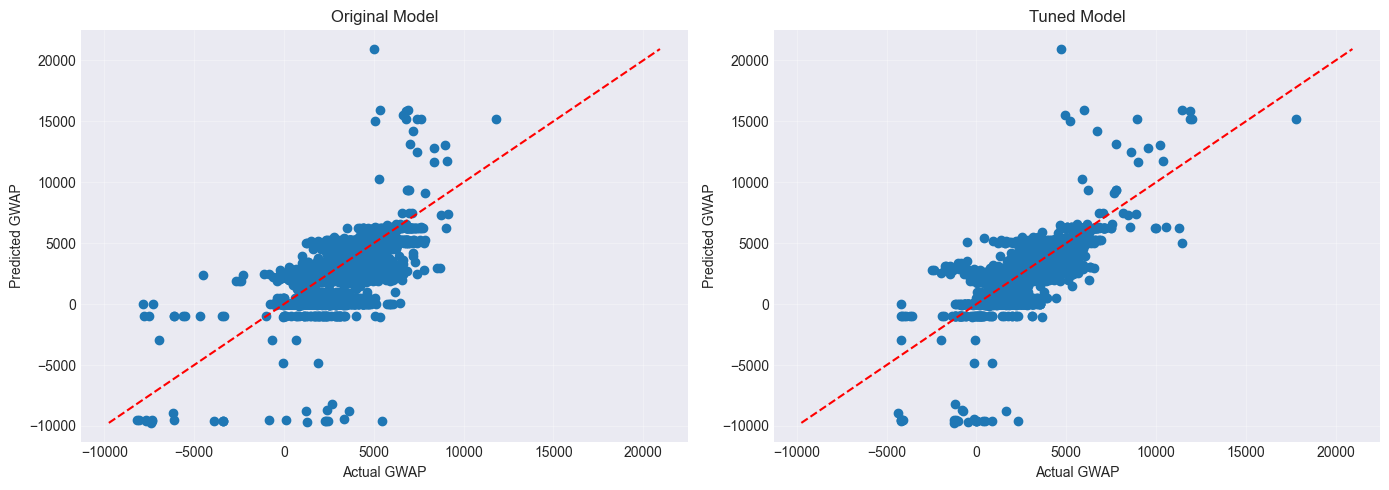

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original model
axes[0].scatter(y_test_pred, y_test_original)
axes[0].set_xlabel("Actual GWAP")
axes[0].set_ylabel("Predicted GWAP")
axes[0].set_title("Original Model")
axes[0].plot([min(y_test_original), max(y_test_original)],
             [min(y_test_original), max(y_test_original)],
             'r--')  # perfect prediction line
axes[0].grid(True, alpha=0.3)

# Tuned model
axes[1].scatter(tuned_y_test_pred, y_test_original)
axes[1].set_xlabel("Actual GWAP")
axes[1].set_ylabel("Predicted GWAP")
axes[1].set_title("Tuned Model")
axes[1].plot([min(y_test_original), max(y_test_original)],
             [min(y_test_original), max(y_test_original)],
             'r--')  # perfect prediction line
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

As seen by the plot, it performed better than the untuned model. Although it is an improvement from before, there are still some discrepancies left. Some values around -₱5000 to ₱0 were predicted to be -₱10,000, a value of higher magnitude, this might be due to the nature of our data. Similarly, at around ₱5,000 to ₱10,000, our model predicts some values as higher than its ground truth.

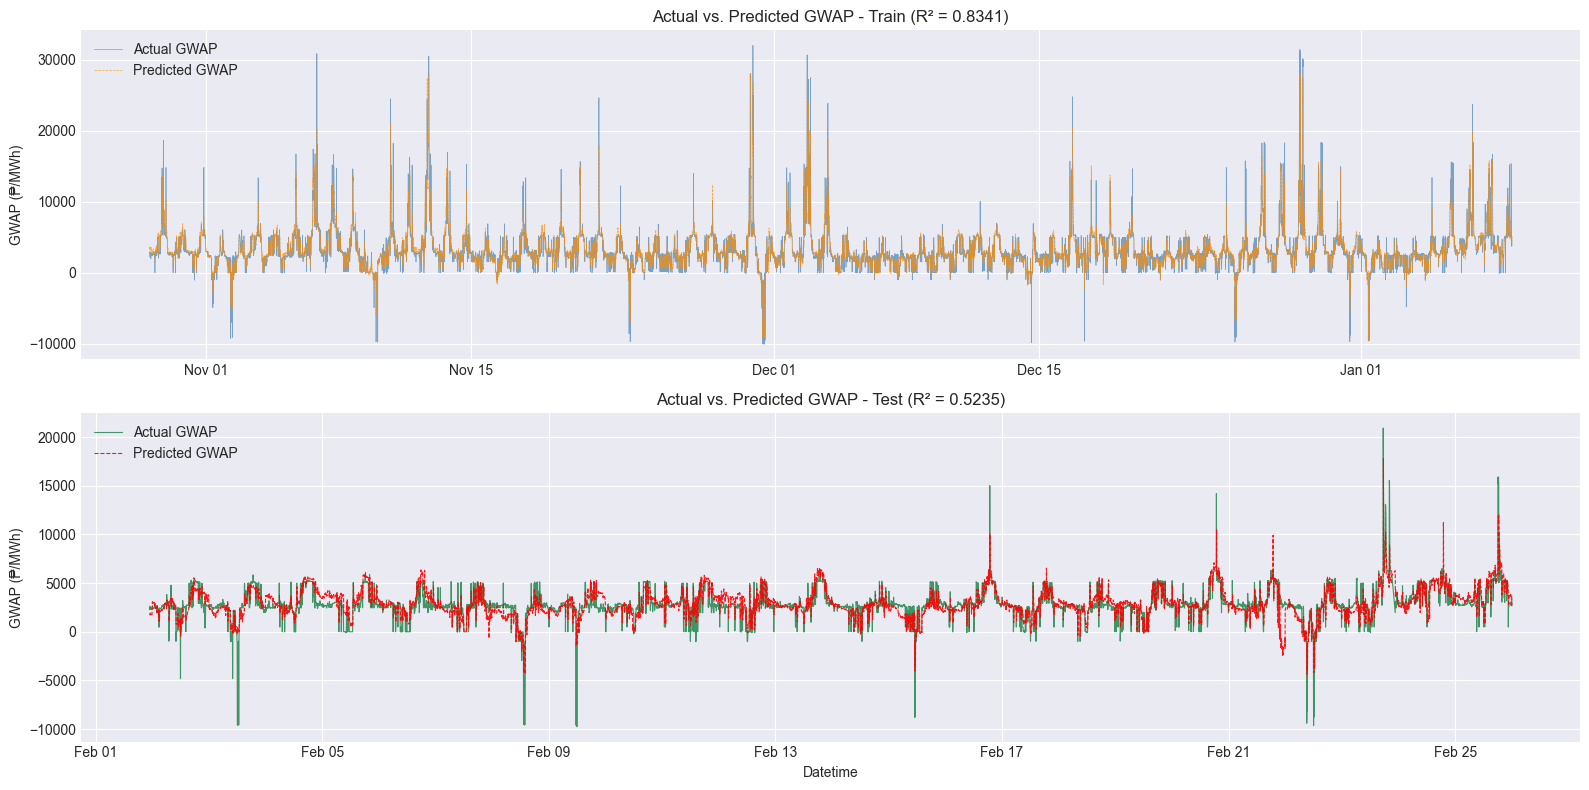

Train GWAP std : 2918.76
Test GWAP std      : 1630.23


In [33]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Train+Val
axes[0].plot(train_df["datetime"].values, scaler_y.inverse_transform(y_train.numpy()), color="steelblue", linewidth=0.5, alpha=0.7, label="Actual GWAP")
axes[0].plot(train_df["datetime"].values, scaler_y.inverse_transform(tuned_model(X_train).detach().numpy()), color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--", label="Predicted GWAP")
axes[0].set_title("Actual vs. Predicted GWAP - Train (R² = 0.8341)")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].legend(loc="upper left")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Test
axes[1].plot(test_df["datetime"].values, y_test_original, color="seagreen",  linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[1].plot(test_df["datetime"].values, tuned_y_test_pred,   color="red",       linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[1].set_title("Actual vs. Predicted GWAP - Test (R² = 0.5235)")
axes[1].set_ylabel("GWAP (₱/MWh)")
axes[1].set_xlabel("Datetime")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

print(f"Train GWAP std : {scaler_y.inverse_transform(y_train.numpy()).std():.2f}")
print(f"Test GWAP std      : {y_test_original.std():.2f}")

Looking at the training data, the model does relatively well in following the pattern even with the occurence of spikes and outliers. But when looking at the test data, it is evident that the mmodel struggles when it comes to the spikes because while it can detect it, the magnitude often falls short of the actual value. It also has a tendency to predict higher when it comes to regular GWAPs.

---

## Interpretation

We shall use **shap** (SHapley Additive exPlanations) for interpreting which feature had the highest contribution to the model's predictions.

In [39]:
import shap
import torch

# convert to numpy
X_background = X_train[:100].detach().cpu().numpy()
X_test_np = X_test.detach().cpu().numpy()

# create prediction function
def f(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    return tuned_model(x_tensor).detach().cpu().numpy()

explainer = shap.Explainer(f, X_background)
shap_values = explainer(X_test_np)

PermutationExplainer explainer: 6908it [02:19, 46.04it/s]                          


Now let us plot the results to see which feature had the most influence in our final model. 

C:\Users\gabri\AppData\Local\Temp\ipykernel_2652\654076416.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_np, feature_names=FEATURE_COLS)


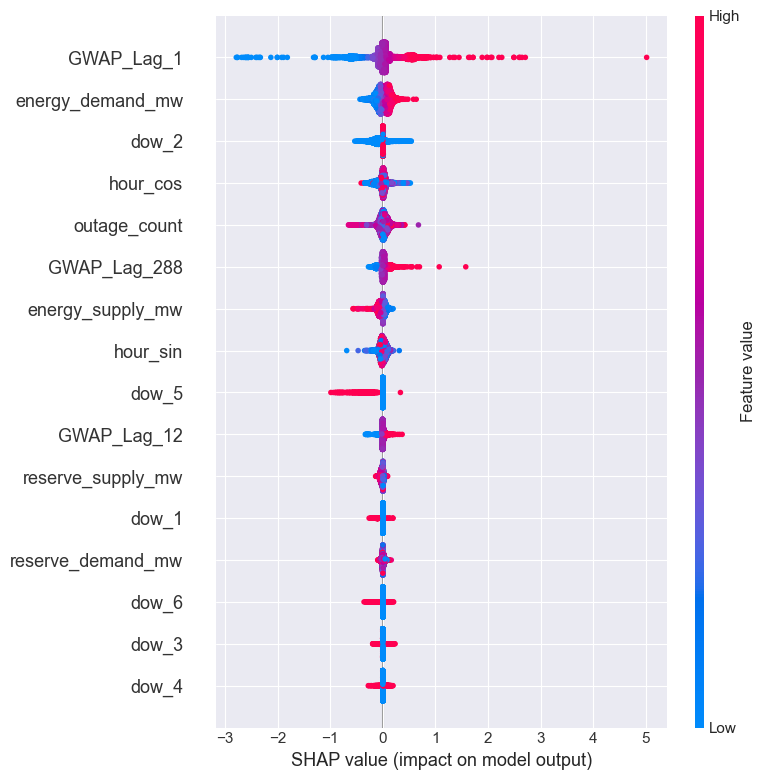

In [40]:
shap.summary_plot(shap_values, X_test_np, feature_names=FEATURE_COLS)

`GWAP_Lag_1`, which is the price 5 minutes ago, is expectedly the feature with the most influence on the model by a large margin. However, it is essential to note that `GWAP_Lag_12` and `GWAP_Lag_288` are surprisingly not as dominant. This tells us that prices that were retrieved later than an hour do not matter as much as expected.

This is followed by `enerygy_demand_mw`, which is expected since higher demand leads to higher prices.

And the features with the least influence are the `dow_n` (days of the week), except for `dow_2`, which might be because office and commercial activities resume at this day.

---

## Error Analysis

To quantify where errors are concentrated, we segment the test set by GWAP range and compute RMSE and MAE per segment.

In [41]:
error_df = test_df[["datetime", "GWAP"]].copy()
error_df["predicted"] = tuned_y_test_pred
error_df["residual"]  = error_df["GWAP"] - error_df["predicted"]
error_df["abs_error"] = error_df["residual"].abs()

# Segment by GWAP range
bins   = [-10000, 0, 2000, 5000, 10000, 35000]
labels = ["Negative", "0-2k", "2k-5k", "5k-10k", ">10k"]
error_df["gwap_segment"] = pd.cut(error_df["GWAP"], bins=bins, labels=labels)

segment_summary = error_df.groupby("gwap_segment", observed=True).agg(
    count      = ("GWAP", "count"),
    mean_gwap  = ("GWAP", "mean"),
    rmse       = ("residual", lambda x: np.sqrt((x**2).mean())),
    mae        = ("abs_error", "mean")
).reset_index()

print(segment_summary.to_string(index=False))

gwap_segment  count    mean_gwap        rmse         mae
    Negative    459  -695.253988 2435.831038 1511.390081
        0-2k    411  1084.738367 1365.181979 1096.012478
       2k-5k   5219  2806.565112  823.711666  602.867924
      5k-10k    800  5302.908570 1059.154948  733.507299
        >10k     18 14405.645722 6745.490676 5641.767203


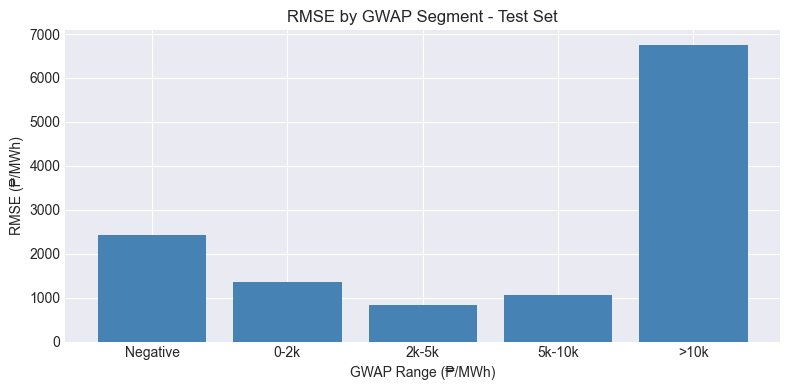

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(segment_summary["gwap_segment"].astype(str), segment_summary["rmse"], color="steelblue")
ax.set_title("RMSE by GWAP Segment - Test Set")
ax.set_xlabel("GWAP Range (₱/MWh)")
ax.set_ylabel("RMSE (₱/MWh)")
plt.tight_layout()
plt.show()

- **Normal range (₱2,000-₱5,000)**: This is 5,219 of 6,907 test intervals (~75.6%) has an RMSE of only ₱823.71. It appears that the model performs best within this range.
- **₱5,000-₱10,000**: In this range, the RMSE rises to ₱1,059.15. It seems to have a tendency to predict lower than the actual price.
- **Negative GWAP**: (459 intervals, ~6.6% of test) This gives us an RMSE of ₱2,435.83. These over-generation events are abrupt and driven by non-linear strategic bidding behavior that a linear model cannot replicate.
- **Above ₱10,000** (only 18 intervals) has an RMSE of ₱6,745.49 (over 8x the normal-range error). The model performs the worst when it comes to these spikes, understandably as they are a rare occurence in our dataset.